# Plot database
Make quick plots of the CTD database

In [1]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
import math
import cmocean
from geopy import distance
from scipy.stats import cumfreq
from scipy.interpolate import griddata
import shapefile
import xarray as xr

dmin=260

%matplotlib widget 
# Autosave every second:
%autosave 1

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Autosaving every 1 seconds


In [2]:
database_file = "../data/Level3/L3_comb.nc"
data_CTD=xr.open_dataset(database_file,decode_times=False)
tnum=data_CTD["time"].values
ds = xr.decode_cf(xr.Dataset({"time": ("time", data_CTD.time.data,{"units":"seconds since 1970-01-01"})}))
data_CTD["time"]=ds["time"].data

In [3]:
ind_deepprof=np.where(data_CTD.max_depth.values>dmin)[0]

In [4]:
print(data_CTD)

<xarray.Dataset>
Dimensions:       (time: 2581, depth_interp: 2400)
Coordinates:
  * time          (time) datetime64[ns] 2008-02-12T10:09:18 ... 2022-09-20T13...
  * depth_interp  (depth_interp) float64 0.0 0.2 0.4 0.6 ... 479.4 479.6 479.8
Data variables: (12/21)
    datetime      (time) float64 ...
    min_depth     (time) float64 ...
    max_depth     (time) float64 157.8 157.6 158.4 153.8 ... 325.8 321.0 324.0
    Press         (depth_interp, time) float64 ...
    Temp          (depth_interp, time) float64 ...
    Cond          (depth_interp, time) float64 ...
    ...            ...
    SALIN         (depth_interp, time) float64 ...
    Cond20        (depth_interp, time) float64 ...
    latitude      (time) float64 ...
    longitude     (time) float64 ...
    dist_GEF      (time) float64 ...
    data_type     (time) float64 ...
Attributes:
    institution:  Eawag
    references:   james.runnalls@eawag.ch
    history:      See history on Renku
    conventions:  CF 1.7
    comment:  

## Interpolated grid for deep profiles

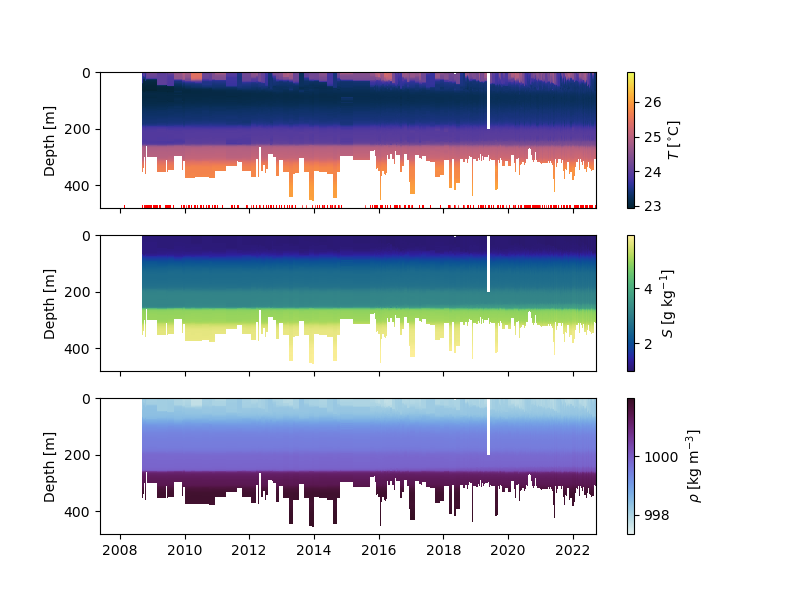

In [6]:
fig,ax = plt.subplots(3,1,figsize=(8,6),sharey=True,sharex=True)
x,y = np.meshgrid(data_CTD["time"][ind_deepprof],data_CTD["depth_interp"])
ptemp = ax[0].pcolormesh(x,y,data_CTD["Temp"][:,ind_deepprof],cmap=cmocean.cm.thermal)
cb=fig.colorbar(ptemp, ax=ax[0])
cb.set_label('$T$ [$^{\circ}$C]')
ax[0].set_ylabel('Depth [m]')
ylimval=ax[0].get_ylim()
ax[0].set_ylim(ylimval)
for kprof in np.arange(len(data_CTD.time)):
    ax[0].plot(np.full(2,data_CTD.time[kprof]),np.array([ylimval[1]-10,ylimval[1]]),'-r',linewidth=0.5)

psal = ax[1].pcolormesh(x,y,data_CTD["SALIN"][:,ind_deepprof],cmap=cmocean.cm.haline)
cb=fig.colorbar(psal, ax=ax[1])
cb.set_label('$S$ [g kg$^{-1}$]')
ax[1].set_ylabel('Depth [m]')


prho = ax[2].pcolormesh(x,y,data_CTD["rho"][:,ind_deepprof],cmap=cmocean.cm.dense)
cb=fig.colorbar(prho, ax=ax[2])
cb.set_label('$\\rho$ [kg m$^{-3}$]')
ax[2].set_ylabel('Depth [m]')

ax[0].invert_yaxis()


## Specific profiles

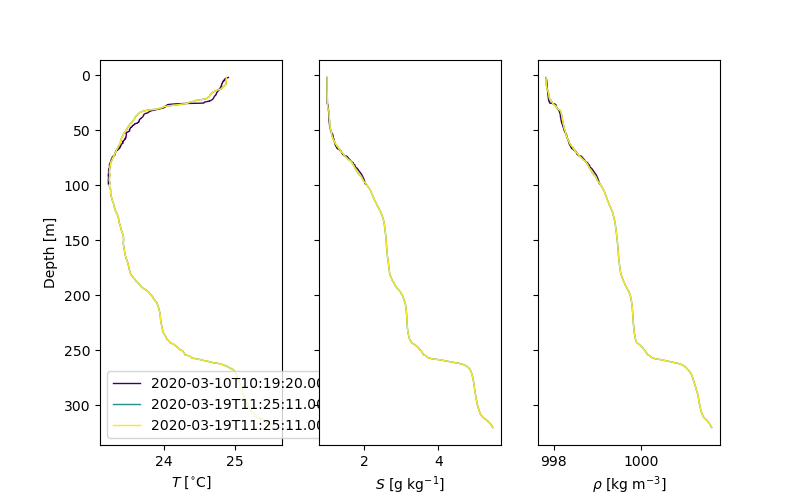

In [7]:
timeprof=[datetime(2020,3,10),datetime(2020,3,17,0,0,0),datetime(2020,3,17,12,0,0)]
timereal=[None]*len(timeprof)
indprof=np.full((len(timeprof),),np.nan)
col_prof=plt.get_cmap('viridis',len(timeprof))

fig,ax = plt.subplots(1,3,figsize=(8,5),sharey=True)
for k in range(len(indprof)):
    indval=np.argmin(np.abs(tnum-timeprof[k].replace(tzinfo=timezone.utc).timestamp()))
    indprof[k]=indval
    timereal[k]=data_CTD["time"].values[indval]
    ax[0].plot(data_CTD["Temp"].values[:,indval],data_CTD["depth_interp"].values,linewidth=1,color=col_prof(k))
    ax[1].plot(data_CTD["SALIN"].values[:,indval],data_CTD["depth_interp"].values,linewidth=1,color=col_prof(k))
    ax[2].plot(data_CTD["rho"].values[:,indval],data_CTD["depth_interp"].values,linewidth=1,color=col_prof(k))
ax[0].set_xlabel('$T$ [$^{\circ}$C]')
ax[0].set_ylabel('Depth [m]')
ax[1].set_xlabel('$S$ [g kg$^{-1}$]')
ax[2].set_xlabel('$\\rho$ [kg m$^{-3}$]')
ax[0].invert_yaxis()
ax[0].legend(timereal)

In [14]:
data_CTD.close()